In [ ]:
!pip install numpy matplotlib scikit-learn

In [2]:
import math
import heapq

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
# ============================================================
# MAPA DA CIDADE
# ============================================================
# As coordenadas representam uma pequena região da cidade.
# Os valores das ruas representam a distância em km.

pontos = {
    "Restaurante": (0, 5),
    "Centro": (2, 5),
    "Mercado": (4, 5),
    "Escola": (2, 3),
    "Hospital": (4, 3),
    "Shopping": (6, 3),
    "Bairro_A": (2, 1),
    "Bairro_B": (4, 1),
    "Bairro_C": (6, 1)
}


# Grafo: cada ligação representa uma rua
grafo = {
    "Restaurante": {"Centro": 2},

    "Centro": {
        "Restaurante": 2,
        "Mercado": 2,
        "Escola": 2
    },

    "Mercado": {
        "Centro": 2,
        "Hospital": 2
    },

    "Escola": {
        "Centro": 2,
        "Hospital": 2,
        "Bairro_A": 2
    },

    "Hospital": {
        "Mercado": 2,
        "Escola": 2,
        "Shopping": 2,
        "Bairro_B": 2
    },

    "Shopping": {
        "Hospital": 2,
        "Bairro_C": 2
    },

    "Bairro_A": {
        "Escola": 2,
        "Bairro_B": 2
    },

    "Bairro_B": {
        "Hospital": 2,
        "Bairro_A": 2,
        "Bairro_C": 2
    },

    "Bairro_C": {
        "Shopping": 2,
        "Bairro_B": 2
    }
}

print("Mapa e grafo carregados com sucesso!")

Mapa e grafo carregados com sucesso!


In [5]:
# ============================================================
# HEURÍSTICA
# ============================================================
# Calcula a distância estimada entre dois pontos.
# O A* utiliza essa informação para escolher caminhos melhores.

def heuristica(a, b):

    x1, y1 = pontos[a]
    x2, y2 = pontos[b]

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

print("Função heurística criada!")



# ============================================================
# ALGORITMO A*
# ============================================================
# f(n) = custo percorrido + estimativa até o destino

def a_star(inicio, destino):

    fila = [(0, inicio)]

    custo = {
        inicio: 0
    }

    anterior = {}

    while fila:

        _, atual = heapq.heappop(fila)

        # Quando chega ao destino
        if atual == destino:

            caminho = []

            while atual in anterior:
                caminho.append(atual)
                atual = anterior[atual]

            caminho.append(inicio)

            caminho.reverse()

            return caminho, custo[destino]

        # Analisa os pontos vizinhos
        for vizinho, distancia in grafo[atual].items():

            novo_custo = custo[atual] + distancia

            if (
                vizinho not in custo
                or novo_custo < custo[vizinho]
            ):

                custo[vizinho] = novo_custo

                prioridade = (
                    novo_custo +
                    heuristica(vizinho, destino)
                )

                heapq.heappush(
                    fila,
                    (prioridade, vizinho)
                )

                anterior[vizinho] = atual

    return [], float("inf")


print("Algoritmo A* criado com sucesso!")

Função heurística criada!
Algoritmo A* criado com sucesso!


In [6]:
# ============================================================
# ENTREGAS
# ============================================================

entregas = [
    "Centro",
    "Mercado",
    "Escola",
    "Bairro_B",
    "Bairro_C"
]


# ============================================================
# DEFINIÇÃO DA ROTA
# ============================================================
# A cada etapa, o sistema procura a entrega mais próxima
# usando o custo encontrado pelo A*.

def criar_rota():

    atual = "Restaurante"

    restantes = entregas.copy()

    rota_final = [atual]

    distancia_total = 0

    while restantes:

        melhor_entrega = None
        melhor_custo = float("inf")
        melhor_caminho = []

        for entrega in restantes:

            caminho, custo = a_star(
                atual,
                entrega
            )

            if custo < melhor_custo:

                melhor_entrega = entrega
                melhor_custo = custo
                melhor_caminho = caminho

        rota_final.extend(
            melhor_caminho[1:]
        )

        distancia_total += melhor_custo

        atual = melhor_entrega

        restantes.remove(
            melhor_entrega
        )

    return rota_final, distancia_total


# Executa a rota
rota, distancia = criar_rota()

print("Rota calculada com sucesso!")

Rota calculada com sucesso!


In [7]:
# ============================================================
# K-MEANS
# ============================================================
# O K-Means agrupa entregas próximas em regiões.
# Neste exemplo serão utilizadas 2 regiões.

coordenadas_entregas = np.array([
    pontos["Centro"],
    pontos["Mercado"],
    pontos["Escola"],
    pontos["Bairro_B"],
    pontos["Bairro_C"]
])


kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

grupos = kmeans.fit_predict(
    coordenadas_entregas
)

centroides = kmeans.cluster_centers_

print("Agrupamento realizado com sucesso!")

Agrupamento realizado com sucesso!


In [8]:
# ============================================================
# RESULTADOS
# ============================================================

print("=" * 55)
print("        SABOR EXPRESS - ROTA INTELIGENTE")
print("=" * 55)

print("\nRota encontrada pelo A*:")

print(" -> ".join(rota))

print(
    f"\nDistância total estimada: "
    f"{distancia:.1f} km"
)

print("\nAgrupamento das entregas:")

for i, entrega in enumerate(entregas):

    print(
        f"{entrega} -> Região {grupos[i] + 1}"
    )

print(
    "\nQuantidade de entregas:",
    len(entregas)
)

print(
    "Quantidade de regiões:",
    2
)

        SABOR EXPRESS - ROTA INTELIGENTE

Rota encontrada pelo A*:
Restaurante -> Centro -> Mercado -> Centro -> Escola -> Bairro_A -> Bairro_B -> Bairro_C

Distância total estimada: 14.0 km

Agrupamento das entregas:
Centro -> Região 1
Mercado -> Região 1
Escola -> Região 1
Bairro_B -> Região 2
Bairro_C -> Região 2

Quantidade de entregas: 5
Quantidade de regiões: 2


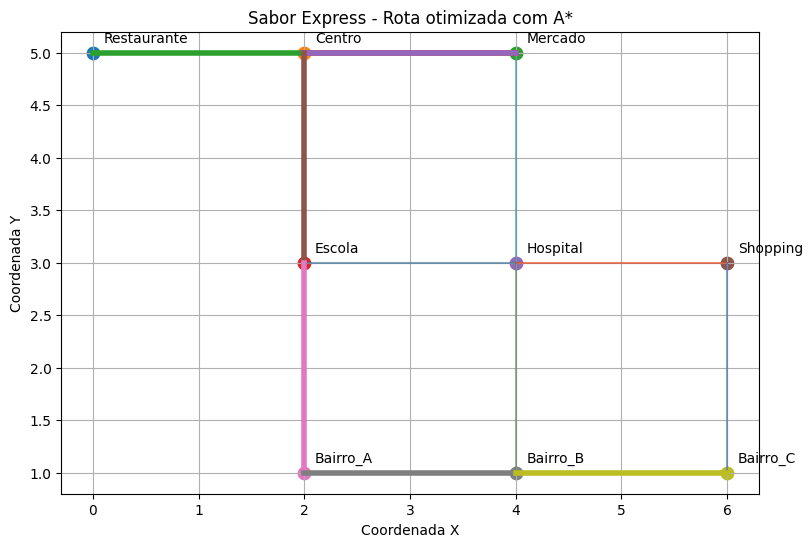

In [9]:
# ============================================================
# GRÁFICO DO GRAFO E DA ROTA
# ============================================================

plt.figure(figsize=(9, 6))


# Desenha as ruas
for origem in grafo:

    for destino in grafo[origem]:

        x1, y1 = pontos[origem]
        x2, y2 = pontos[destino]

        plt.plot(
            [x1, x2],
            [y1, y2],
            alpha=0.4
        )


# Desenha os pontos
for nome, (x, y) in pontos.items():

    plt.scatter(
        x,
        y,
        s=80
    )

    plt.text(
        x + 0.1,
        y + 0.1,
        nome
    )


# Destaca a rota encontrada pelo A*
for i in range(len(rota) - 1):

    x1, y1 = pontos[rota[i]]
    x2, y2 = pontos[rota[i + 1]]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=4
    )


plt.title(
    "Sabor Express - Rota otimizada com A*"
)

plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.grid(True)

plt.show()

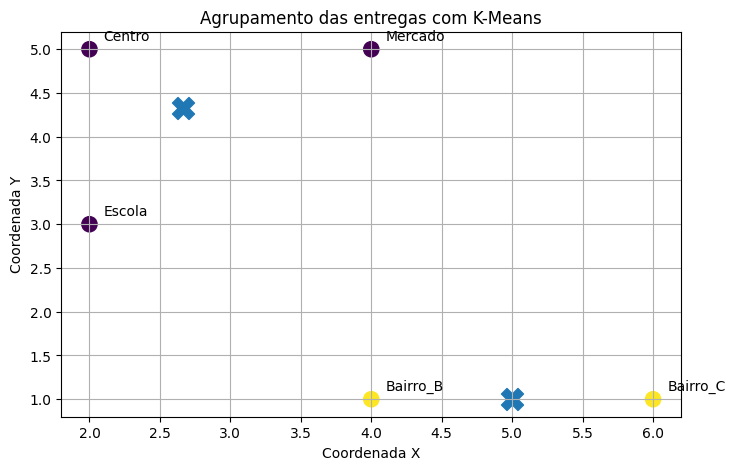

In [10]:
# ============================================================
# GRÁFICO DO K-MEANS
# ============================================================

plt.figure(figsize=(8, 5))


plt.scatter(
    coordenadas_entregas[:, 0],
    coordenadas_entregas[:, 1],
    c=grupos,
    s=120
)


# Mostra os centroides
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    marker="X",
    s=250
)


# Identifica cada entrega
for i, entrega in enumerate(entregas):

    x, y = pontos[entrega]

    plt.text(
        x + 0.1,
        y + 0.1,
        entrega
    )


plt.title(
    "Agrupamento das entregas com K-Means"
)

plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.grid(True)

plt.show()

In [11]:
# ============================================================
# RESUMO DA SOLUÇÃO
# ============================================================

print("\n" + "=" * 55)
print("RESUMO DO PROJETO")
print("=" * 55)

print("\n1. A cidade foi representada como um grafo.")
print("2. O A* foi usado para encontrar caminhos eficientes.")
print("3. O K-Means agrupou entregas próximas.")
print("4. Os gráficos mostram a rota e as regiões.")
print("5. A solução busca reduzir deslocamentos desnecessários.")


RESUMO DO PROJETO

1. A cidade foi representada como um grafo.
2. O A* foi usado para encontrar caminhos eficientes.
3. O K-Means agrupou entregas próximas.
4. Os gráficos mostram a rota e as regiões.
5. A solução busca reduzir deslocamentos desnecessários.
